# FF49 Conditional Diffusion Pipeline

This notebook calls the refactored `.py` modules from `portfolio_diffusion/`. Put `49_Industry_Portfolios.csv` in `data/` before running.

In [1]:
from pathlib import Path
import sys

# Works whether the notebook is run from repo root or notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from portfolio_diffusion import (
    DDPMConfig,
    ConditionalRecurrentDDPM,
    TrainCfg,
    seed_everything,
    fit,
    build_dataloader,
    load_ff49_monthly_value_weighted_drop_columns,
    split_train_valid_test,
    standardize_train_valid,
    run_generative_markowitz_backtest,
    make_backtest_dataframe,
    performance_stats,
    compute_rebalance_turnover,
    build_weight_dataframe,
    build_average_weights_dataframe,
    save_scenario_dataset_for_rl,
)
from portfolio_diffusion.plotting import plot_wealth, plot_average_weights, plot_turnover

OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

## 1. Load FF49 monthly returns

In [2]:
csv_path = PROJECT_ROOT / "data" / "10_Industry_Portfolios.csv"

monthly_returns_df, dropped_columns, missing_count = load_ff49_monthly_value_weighted_drop_columns(
    csv_path,
    start_date="1929-01-01",
)

industry_names = list(monthly_returns_df.columns)
num_assets = len(industry_names)

print("Monthly data shape:", monthly_returns_df.shape)
print("Monthly date range:", monthly_returns_df.index.min(), "to", monthly_returns_df.index.max())
print("Number of industries kept:", num_assets)
print("Dropped industries:", dropped_columns)

Monthly data shape: (1168, 10)
Monthly date range: 1929-01-01 00:00:00 to 2026-04-01 00:00:00
Number of industries kept: 10
Dropped industries: []


## 2. Split and standardize

In [3]:
train_df, valid_target_df, test_target_df = split_train_valid_test(
    monthly_returns_df,
    train_end="2010-12-31",
    valid_start="2011-01-01",
    valid_end="2015-12-31",
    test_start="2016-01-01",
)

print("Train shape:", train_df.shape, train_df.index.min(), "to", train_df.index.max())
print("Validation shape:", valid_target_df.shape, valid_target_df.index.min(), "to", valid_target_df.index.max())
print("Test shape:", test_target_df.shape, test_target_df.index.min(), "to", test_target_df.index.max())

Train shape: (984, 10) 1929-01-01 00:00:00 to 2010-12-01 00:00:00
Validation shape: (60, 10) 2011-01-01 00:00:00 to 2015-12-01 00:00:00
Test shape: (124, 10) 2016-01-01 00:00:00 to 2026-04-01 00:00:00


## 3. Configure model

In [4]:
seed_everything(42)

cfg = DDPMConfig(
    input_dim=num_assets,
    context_length=36,
    prediction_length=1,
    rnn_type="LSTM",
    rnn_hidden_dim=128,
    rnn_layers=2,
    rnn_dropout=0.05,
    unet_base_channels=64,
    unet_depth=3,
    time_embed_dim=128,
    diffusion_steps=500,
    beta_start=1e-4,
    beta_end=2e-2,
    batch_size=16,
    lr=2e-4,
    epochs=100,
    grad_clip=1.0,
    weight_decay=1e-4,
    device="cuda" if torch.cuda.is_available() else "cpu",
)

device = torch.device(cfg.device)
print("Device:", device)
print("Input dim:", cfg.input_dim)
print("Context length:", cfg.context_length)

Device: cuda
Input dim: 10
Context length: 36


In [5]:
train_returns, valid_returns, mean, std, valid_with_context_df = standardize_train_valid(
    train_df=train_df,
    valid_target_df=valid_target_df,
    context_length=cfg.context_length,
)

print("Train raw shape:", train_df.values.shape)
print("Valid raw with context shape:", valid_with_context_df.values.shape)
print("Train standardized mean avg:", train_returns.mean(axis=0).mean())
print("Train standardized std avg:", train_returns.std(axis=0).mean())

Train raw shape: (984, 10)
Valid raw with context shape: (96, 10)
Train standardized mean avg: -5.330496e-10
Train standardized std avg: 0.9999999


## 4. Dataloaders

The dataset returns repo-style sequence-to-sequence targets with shape `[batch, context_length, prediction_length, num_assets]`.

In [6]:
train_dataset, train_loader = build_dataloader(
    series=train_returns,
    cfg=cfg,
    shuffle=True,
    stride=1,
    normalize=False,
    num_workers=0,
    drop_last=True,
)

valid_dataset, valid_loader = build_dataloader(
    series=valid_returns,
    cfg=cfg,
    shuffle=False,
    stride=1,
    normalize=False,
    num_workers=0,
    drop_last=False,
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(valid_dataset))

batch = next(iter(train_loader))
print("context shape:", batch["context"].shape)
print("target shape:", batch["target"].shape)

Train samples: 948
Validation samples: 60
context shape: torch.Size([16, 36, 10])
target shape: torch.Size([16, 36, 1, 10])


## 5. Train diffusion model

In [7]:
model = ConditionalRecurrentDDPM(cfg).to(device)

train_cfg = TrainCfg(
    optim_name="AdamW",
    lr=cfg.lr,
    weight_decay=cfg.weight_decay,
    scheduler="cosine",
    num_epochs=cfg.epochs,
    use_ema=True,
    ema_decay=0.999,
    max_grad_norm=cfg.grad_clip,
    amp=torch.cuda.is_available(),
    patience=25,
    seed=42,
    save_path=str(OUTPUT_DIR / "best_ff10_monthly_dropcols_pre2011.pt"),
    force_lazy_modules=True,
)

best_model, history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=valid_loader,
    device=device,
    cfg=train_cfg,
)

/home/aghapour/Portfolio/portfolio_diffusion/training.py:279: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=amp_enabled)
Epoch 1/100:   0%|          | 0/59 [00:00<?, ?it/s]/home/aghapour/Portfolio/portfolio_diffusion/training.py:317: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):


[001/100] train=0.363722 val=0.726580 lr=2.00e-04 t=0.1m


[002/100] train=0.280673 val=0.545865 lr=2.00e-04 t=0.1m


[003/100] train=0.273045 val=0.471516 lr=2.00e-04 t=0.1m


[004/100] train=0.269513 val=0.418749 lr=1.99e-04 t=0.2m


...

[053/100] train=0.052070 val=0.278250 lr=9.61e-05 t=2.1m


[054/100] train=0.049434 val=0.269303 lr=9.31e-05 t=2.2m


[055/100] train=0.049365 val=0.287239 lr=9.01e-05 t=2.2m


[056/100] train=0.048784 val=0.293796 lr=8.72e-05 t=2.3m


[057/100] train=0.048234 val=0.313562 lr=8.43e-05 t=2.3m
Early stopping


## 6. Rolling scenario generation and Markowitz backtest

In [8]:
backtest_results = run_generative_markowitz_backtest(
    model=best_model,
    monthly_returns_df=monthly_returns_df,
    test_target_df=test_target_df,
    mean=mean,
    std=std,
    cfg=cfg,
    num_scenarios=500,
    risk_aversion=5.0,
    eta=1.0,
    cov_shrinkage=0.05,
    weight_cap=None,
)

bt_df = make_backtest_dataframe(backtest_results)
bt_df.head()

/home/aghapour/.conda/envs/ldm/lib/python3.8/site-packages/torch/nn/modules/rnn.py:917: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at ../aten/src/ATen/native/cudnn/RNN.cpp:1424.)
  result = _VF.lstm(input, hx, self._flat_weights, self.bias, self.num_layers,
/home/aghapour/.conda/envs/ldm/lib/python3.8/site-packages/torch/nn/modules/rnn.py:917: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at ../aten/src/ATen/native/cudnn/RNN.cpp:1424.)
  result = _VF.lstm(input, hx, self._flat_weights, self.bias, self.num_layers,


,Generative_Markowitz_Return,Equal_Weight_Return,Generative_Markowitz_Wealth,Equal_Weight_Wealth
2016-01-01,-0.049953,-0.04652,0.950047,0.953480
2016-02-01,0.009100,0.00550,0.958692,0.958724
2016-03-01,0.060444,0.07256,1.016639,1.028289
2016-04-01,0.003568,0.01578,1.020266,1.044516
2016-05-01,0.006431,0.01066,1.026827,1.055650


## 7. Performance statistics

In [15]:
gm_stats = performance_stats(
    bt_df["Generative_Markowitz_Return"].values,
    wealth=bt_df["Generative_Markowitz_Wealth"].values,
)
ew_stats = performance_stats(
    bt_df["Equal_Weight_Return"].values,
    wealth=bt_df["Equal_Weight_Wealth"].values,
)

stats_df = pd.DataFrame({"Generative Markowitz": gm_stats, "1/N Equal Weight": ew_stats})
stats_df

,Generative Markowitz,1/N Equal Weight
Months,124.000000,124.000000
Final Wealth,4.460527,3.715682
Annual Return,0.155697,0.135442
Annual Volatility,0.209298,0.154822
Sharpe,0.743901,0.874825
Sortino,1.445632,1.241074
Max Drawdown,-0.201265,-0.229258
Monthly Mean,0.013828,0.011641
Monthly Std,0.060419,0.044693
Best Month,0.409900,0.148860


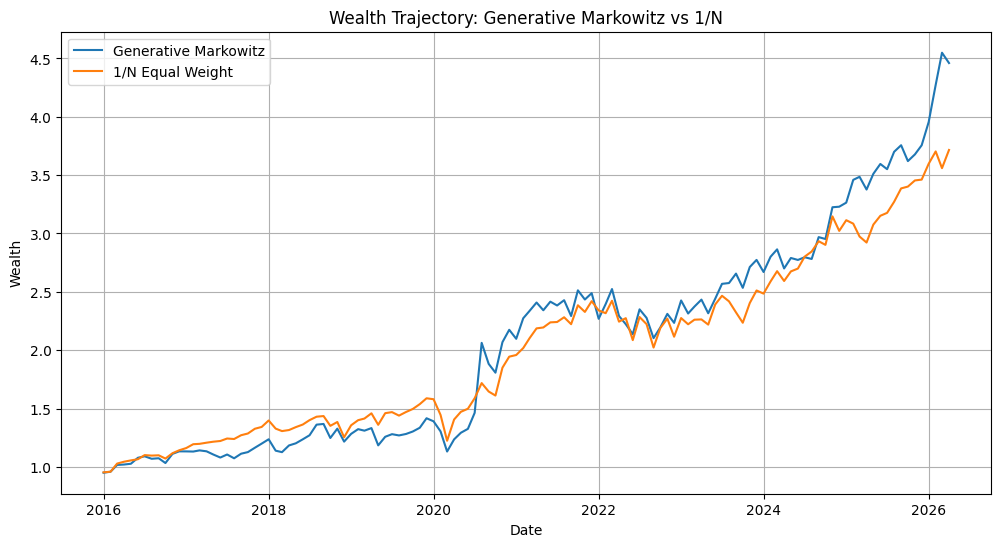

In [9]:
fig, ax = plot_wealth(bt_df)
plt.show()

## 8. Weights and turnover

In [10]:
weights_df = build_weight_dataframe(backtest_results, industry_names)
avg_weights_df = build_average_weights_dataframe(weights_df)
avg_weights_df.head(20)

,Industry,Average_GM_Weight,Equal_Weight
5,Telcm,0.330417,0.1
3,Enrgy,0.184006,0.1
7,Hlth,0.134513,0.1
6,Shops,0.122200,0.1
1,Durbl,0.071209,0.1
0,NoDur,0.060491,0.1
4,HiTec,0.051653,0.1
8,Utils,0.026556,0.1
2,Manuf,0.010223,0.1
9,Other,0.008730,0.1


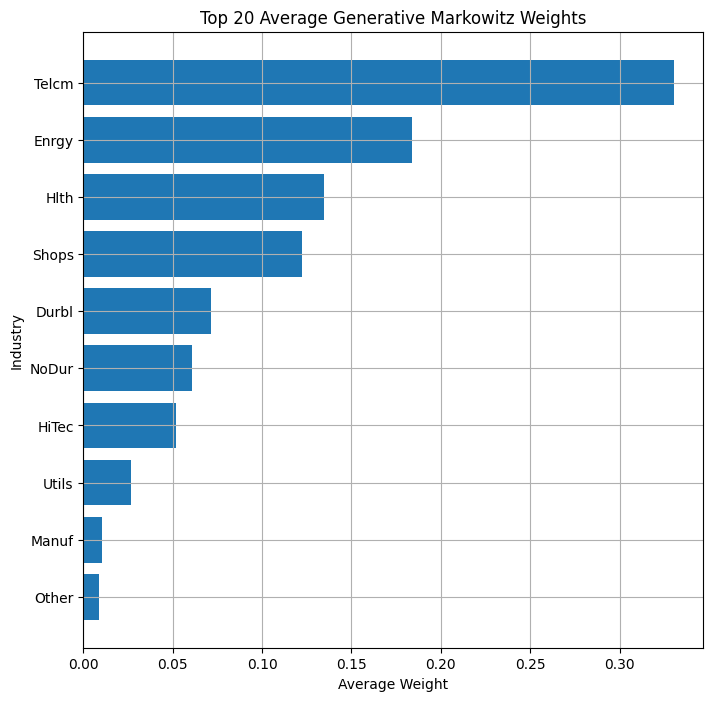

In [11]:
fig, ax = plot_average_weights(avg_weights_df, top_n=20)
plt.show()

Average monthly turnover: 1.0510366474024782
Median monthly turnover: 1.0190797706389472
Max monthly turnover: 1.9999998984798821


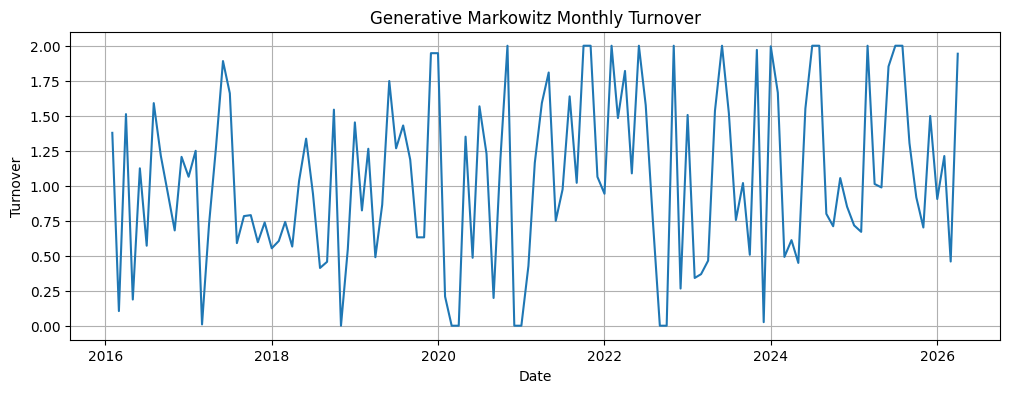

In [12]:
# Simple target-to-target turnover, matching the original notebook.
turnover = np.abs(backtest_results["gm_weights"][1:] - backtest_results["gm_weights"][:-1]).sum(axis=1)
turnover_df = pd.DataFrame({"Turnover": turnover}, index=backtest_results["dates"][1:])

print("Average monthly turnover:", turnover.mean())
print("Median monthly turnover:", np.median(turnover))
print("Max monthly turnover:", turnover.max())

fig, ax = plot_turnover(turnover_df)
plt.show()

In [13]:
# More realistic drift-adjusted turnover for both strategies.
R_test = backtest_results["actual_next_returns"]
W_gm = backtest_results["gm_weights"]
T, N = R_test.shape
W_ew = np.ones((T, N)) / N

turnover_gm = compute_rebalance_turnover(W_gm, R_test)
turnover_ew = compute_rebalance_turnover(W_ew, R_test)

print("Drift-adjusted GM turnover:", turnover_gm.mean())
print("Drift-adjusted 1/N turnover:", turnover_ew.mean())

Drift-adjusted GM turnover: 1.0472880733167995
Drift-adjusted 1/N turnover: 0.036865714393024065


## 9. Save results and RL scenario dataset

In [16]:
bt_df.to_csv(OUTPUT_DIR / "backtest_generative_markowitz_vs_equal_weight__ff10.csv")
weights_df.to_csv(OUTPUT_DIR / "generative_markowitz_monthly_weights_ff10.csv")
stats_df.to_csv(OUTPUT_DIR / "performance_stats_ff10.csv")
avg_weights_df.to_csv(OUTPUT_DIR / "average_weights_ff10.csv")

saved_paths = save_scenario_dataset_for_rl(
    backtest_results=backtest_results,
    asset_names=industry_names,
    output_dir=OUTPUT_DIR,
    prefix="ff49_diffusion",
)

print("Saved result CSVs to", OUTPUT_DIR)
for name, path in saved_paths.items():
    print(name, "->", path)

Saved result CSVs to /home/aghapour/Portfolio/outputs
npz -> /home/aghapour/Portfolio/outputs/ff49_diffusion_scenarios_for_rl.npz
scenario_panel_csv -> /home/aghapour/Portfolio/outputs/ff49_diffusion_scenarios_for_rl_panel.csv
actual_returns_csv -> /home/aghapour/Portfolio/outputs/ff49_diffusion_actual_next_returns_for_rl.csv
state_windows_csv -> /home/aghapour/Portfolio/outputs/ff49_diffusion_state_windows_for_rl.csv


In [17]:
# ============================================================
# Risk-aversion comparison using saved/generated scenarios
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

risk_aversions = [0.5, 1.0, 2.0 , 5.0]

# Use generated scenarios already stored in backtest_results
scenarios_raw = backtest_results["scenarios_raw"]              # [T, S, N]
actual_next_returns = backtest_results["actual_next_returns"]  # [T, N]
dates = pd.Index(backtest_results["dates"])
asset_names = list(industry_names)

T, S, N = scenarios_raw.shape

print("scenarios_raw:", scenarios_raw.shape)
print("actual_next_returns:", actual_next_returns.shape)
print("dates:", len(dates))
print("assets:", len(asset_names))


# ============================================================
# Helper functions
# ============================================================

def scenario_mean_cov(scenarios_t, cov_shrinkage=0.05, ridge=1e-6):
    """
    scenarios_t: [num_scenarios, num_assets]
    """
    mu = scenarios_t.mean(axis=0)
    cov = np.cov(scenarios_t, rowvar=False)

    # shrink covariance toward diagonal
    diag_cov = np.diag(np.diag(cov))
    cov = (1.0 - cov_shrinkage) * cov + cov_shrinkage * diag_cov

    cov = cov + ridge * np.eye(cov.shape[0])

    return mu, cov


def long_only_markowitz(mu, cov, risk_aversion=1.0, weight_cap=None):
    """
    Maximize:
        mu'w - 0.5 * gamma * w'Cov w

    subject to:
        sum(w) = 1
        w >= 0
    """
    mu = np.asarray(mu, dtype=np.float64)
    cov = np.asarray(cov, dtype=np.float64)

    n = len(mu)
    x0 = np.ones(n) / n

    def objective(w):
        utility = mu @ w - 0.5 * risk_aversion * (w @ cov @ w)
        return -utility

    constraints = [
        {"type": "eq", "fun": lambda w: np.sum(w) - 1.0}
    ]

    if weight_cap is None:
        bounds = [(0.0, 1.0) for _ in range(n)]
    else:
        bounds = [(0.0, weight_cap) for _ in range(n)]

    res = minimize(
        objective,
        x0=x0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"maxiter": 1000, "ftol": 1e-10, "disp": False},
    )

    if not res.success:
        return x0

    w = np.clip(res.x, 0.0, 1.0)
    w = w / w.sum()

    return w


def compute_turnover(weights, returns):
    """
    weights: [T, N]
    returns: [T, N]

    turnover[t] = sum(abs(target_weight_t - drifted_weight_{t-1}))
    """
    weights = np.asarray(weights, dtype=np.float64)
    returns = np.asarray(returns, dtype=np.float64)

    T, N = weights.shape
    turnover = np.zeros(T)

    turnover[0] = np.sum(np.abs(weights[0]))

    for t in range(1, T):
        prev_w = weights[t - 1]
        prev_r = returns[t - 1]

        prev_port_ret = prev_w @ prev_r

        drifted_w = prev_w * (1.0 + prev_r) / (1.0 + prev_port_ret)
        turnover[t] = np.sum(np.abs(weights[t] - drifted_w))

    return turnover


def performance_stats(returns, periods_per_year=12):
    returns = np.asarray(returns, dtype=np.float64)

    wealth = np.cumprod(1.0 + returns)

    ann_return = wealth[-1] ** (periods_per_year / len(returns)) - 1.0
    ann_vol = returns.std(ddof=1) * np.sqrt(periods_per_year)
    sharpe = ann_return / ann_vol if ann_vol > 1e-12 else np.nan

    downside = returns[returns < 0]
    downside_vol = downside.std(ddof=1) * np.sqrt(periods_per_year) if len(downside) > 1 else np.nan
    sortino = ann_return / downside_vol if downside_vol is not np.nan and downside_vol > 1e-12 else np.nan

    running_max = np.maximum.accumulate(wealth)
    drawdown = wealth / running_max - 1.0

    return {
        "Final Wealth": wealth[-1],
        "Annual Return": ann_return,
        "Annual Volatility": ann_vol,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Max Drawdown": drawdown.min(),
        "Mean Monthly Return": returns.mean(),
        "Monthly Volatility": returns.std(ddof=1),
        "Worst Month": returns.min(),
        "Best Month": returns.max(),
    }

scenarios_raw: (124, 500, 10)
actual_next_returns: (124, 10)
dates: 124
assets: 10


In [18]:
# ============================================================
# Run backtest for gamma = 0.5, 1.0, 2.0
# ============================================================

cov_shrinkage = 0.01
weight_cap = None

# You can later try:
# weight_cap = 0.10
# cov_shrinkage = 0.30

ra_returns = {}
ra_weights = {}
ra_turnover = {}

for gamma in risk_aversions:
    weights_gamma = np.zeros((T, N))
    returns_gamma = np.zeros(T)

    for t in range(T):
        scen_t = scenarios_raw[t]  # [S, N]

        mu_t, cov_t = scenario_mean_cov(
            scen_t,
            cov_shrinkage=cov_shrinkage,
        )

        w_t = long_only_markowitz(
            mu=mu_t,
            cov=cov_t,
            risk_aversion=gamma,
            weight_cap=weight_cap,
        )

        weights_gamma[t] = w_t
        returns_gamma[t] = w_t @ actual_next_returns[t]

    ra_returns[gamma] = returns_gamma
    ra_weights[gamma] = weights_gamma
    ra_turnover[gamma] = compute_turnover(weights_gamma, actual_next_returns)


# Equal-weight baseline
ew_weights = np.ones((T, N)) / N
ew_returns = np.sum(ew_weights * actual_next_returns, axis=1)
ew_turnover = compute_turnover(ew_weights, actual_next_returns)

In [19]:
# ============================================================
# Historical rolling 500-month Markowitz benchmark
# ============================================================

LOOKBACK_MONTHS = 500

# Full raw monthly return panel.
# This should be the same raw return DataFrame used before training.
# Rows = months, columns = industries/assets.
returns_panel = monthly_returns_df[industry_names].copy()

# Make sure columns match the assets used in the backtest
returns_panel = returns_panel[asset_names]

print("returns_panel:", returns_panel.shape)
print("backtest dates:", len(dates))
print("actual_next_returns:", actual_next_returns.shape)

returns_panel: (1168, 10)
backtest dates: 124
actual_next_returns: (124, 10)


In [20]:
# ============================================================
# Date alignment helpers
# ============================================================

def to_month_period_index(x):
    """
    Convert DatetimeIndex, PeriodIndex, strings, or generic Index
    to monthly PeriodIndex.
    """
    idx = pd.Index(x)

    if isinstance(idx, pd.PeriodIndex):
        return idx.asfreq("M")

    if isinstance(idx, pd.DatetimeIndex):
        return idx.to_period("M")

    try:
        return pd.PeriodIndex(idx.astype(str), freq="M")
    except Exception:
        return pd.to_datetime(idx).to_period("M")


panel_months = to_month_period_index(returns_panel.index)
test_months = to_month_period_index(dates)

# Map each month to its row position in the full return panel
month_to_pos = {m: i for i, m in enumerate(panel_months)}

missing_months = [m for m in test_months if m not in month_to_pos]

if len(missing_months) > 0:
    raise ValueError(
        f"Some backtest months are missing from returns_panel. "
        f"First missing months: {missing_months[:5]}"
    )

print("Date alignment OK.")

Date alignment OK.


In [21]:
# ============================================================
# Historical mean/covariance estimation from previous 500 months
# ============================================================

def historical_mean_cov_for_month(
    target_month,
    returns_panel,
    panel_months,
    lookback=500,
    cov_shrinkage=0.05,
    ridge=1e-6,
):
    """
    Estimate mu and covariance using only months before target_month.

    target_month:
        monthly Period, e.g. Period('2016-01', 'M')

    returns_panel:
        full raw return DataFrame [T_full, N]

    panel_months:
        PeriodIndex aligned with returns_panel rows

    lookback:
        number of previous months to use
    """
    pos = month_to_pos[target_month]

    start = max(0, pos - lookback)
    end = pos  # exclude target month itself

    hist = returns_panel.iloc[start:end].values.astype(np.float64)

    if hist.shape[0] < 12:
        raise ValueError(
            f"Too few historical observations before {target_month}: {hist.shape[0]}"
        )

    mu = hist.mean(axis=0)
    cov = np.cov(hist, rowvar=False)

    # shrink covariance toward diagonal
    diag_cov = np.diag(np.diag(cov))
    cov = (1.0 - cov_shrinkage) * cov + cov_shrinkage * diag_cov

    cov = cov + ridge * np.eye(cov.shape[0])

    return mu, cov, hist.shape[0]

In [22]:
# ============================================================
# Run Historical 500M Markowitz for each risk aversion
# ============================================================

hist500_returns = {}
hist500_weights = {}
hist500_turnover = {}
hist500_obs_used = {}

hist_cov_shrinkage = 0.01
hist_weight_cap = None

# Optional robustness:
# hist_weight_cap = 0.10
# hist_cov_shrinkage = 0.30

for gamma in risk_aversions:
    weights_gamma = np.zeros((T, N))
    returns_gamma = np.zeros(T)
    obs_used_gamma = np.zeros(T, dtype=int)

    for t, month in enumerate(test_months):
        mu_t, cov_t, n_obs_t = historical_mean_cov_for_month(
            target_month=month,
            returns_panel=returns_panel,
            panel_months=panel_months,
            lookback=LOOKBACK_MONTHS,
            cov_shrinkage=hist_cov_shrinkage,
        )

        w_t = long_only_markowitz(
            mu=mu_t,
            cov=cov_t,
            risk_aversion=gamma,
            weight_cap=hist_weight_cap,
        )

        weights_gamma[t] = w_t
        returns_gamma[t] = w_t @ actual_next_returns[t]
        obs_used_gamma[t] = n_obs_t

    hist500_returns[gamma] = returns_gamma
    hist500_weights[gamma] = weights_gamma
    hist500_turnover[gamma] = compute_turnover(weights_gamma, actual_next_returns)
    hist500_obs_used[gamma] = obs_used_gamma

print("Historical 500-month Markowitz benchmark complete.")

Historical 500-month Markowitz benchmark complete.


In [23]:
# ============================================================
# Combined performance table
# ============================================================

combined_rows = []

for gamma in risk_aversions:
    stats = performance_stats(ra_returns[gamma])
    stats["Strategy"] = f"Generated_GM_gamma_{gamma}"
    stats["Estimator"] = "Diffusion scenarios"
    stats["Risk Aversion"] = gamma
    stats["Lookback Months"] = np.nan
    stats["Average Turnover"] = ra_turnover[gamma].mean()
    stats["Median Turnover"] = np.median(ra_turnover[gamma])
    stats["Max Turnover"] = ra_turnover[gamma].max()
    combined_rows.append(stats)

for gamma in risk_aversions:
    stats = performance_stats(hist500_returns[gamma])
    stats["Strategy"] = f"Historical500_GM_gamma_{gamma}"
    stats["Estimator"] = "Historical 500-month mean/cov"
    stats["Risk Aversion"] = gamma
    stats["Lookback Months"] = LOOKBACK_MONTHS
    stats["Average Turnover"] = hist500_turnover[gamma].mean()
    stats["Median Turnover"] = np.median(hist500_turnover[gamma])
    stats["Max Turnover"] = hist500_turnover[gamma].max()
    combined_rows.append(stats)

ew_stats = performance_stats(ew_returns)
ew_stats["Strategy"] = "Equal_Weight_1_over_N"
ew_stats["Estimator"] = "Equal weight"
ew_stats["Risk Aversion"] = np.nan
ew_stats["Lookback Months"] = np.nan
ew_stats["Average Turnover"] = ew_turnover.mean()
ew_stats["Median Turnover"] = np.median(ew_turnover)
ew_stats["Max Turnover"] = ew_turnover.max()
combined_rows.append(ew_stats)

combined_stats_df = pd.DataFrame(combined_rows)

combined_stats_df = combined_stats_df[
    [
        "Strategy",
        "Estimator",
        "Risk Aversion",
        "Lookback Months",
        "Final Wealth",
        "Annual Return",
        "Annual Volatility",
        "Sharpe",
        "Sortino",
        "Max Drawdown",
        "Mean Monthly Return",
        "Monthly Volatility",
        "Worst Month",
        "Best Month",
        "Average Turnover",
        "Median Turnover",
        "Max Turnover",
    ]
]

display(combined_stats_df)

,Strategy,Estimator,Risk Aversion,Lookback Months,Final Wealth,Annual Return,Annual Volatility,Sharpe,Sortino,Max Drawdown,Mean Monthly Return,Monthly Volatility,Worst Month,Best Month,Average Turnover,Median Turnover,Max Turnover
0,Generated_GM_gamma_0.5,Diffusion scenarios,0.5,NaN,7.764540,0.219383,0.236246,0.928623,1.893049,-0.197082,0.018819,0.068198,-0.132200,0.409900,1.145473,1.937692,2.000000
1,Generated_GM_gamma_1.0,Diffusion scenarios,1.0,NaN,7.548256,0.216054,0.234359,0.921895,1.838273,-0.199909,0.018556,0.067654,-0.132200,0.409900,1.121163,1.222242,2.000000
2,Generated_GM_gamma_2.0,Diffusion scenarios,2.0,NaN,6.223143,0.193547,0.227599,0.850389,1.647909,-0.201890,0.016855,0.065702,-0.132200,0.409900,1.124665,1.124337,2.000000
3,Generated_GM_gamma_5.0,Diffusion scenarios,5.0,NaN,4.474799,0.156054,0.211582,0.737558,1.419702,-0.202739,0.013879,0.061078,-0.132200,0.409900,1.058498,1.019289,2.000000
4,Historical500_GM_gamma_0.5,Historical 500-month mean/cov,0.5,500.0,2.123740,0.075610,0.149249,0.506607,0.739332,-0.261897,0.007017,0.043084,-0.105968,0.109782,0.185218,0.097274,1.011489
5,Historical500_GM_gamma_1.0,Historical 500-month mean/cov,1.0,500.0,1.983231,0.068509,0.132700,0.516268,0.751144,-0.215327,0.006269,0.038307,-0.105616,0.103866,0.162257,0.162287,1.000000
6,Historical500_GM_gamma_2.0,Historical 500-month mean/cov,2.0,500.0,1.978804,0.068278,0.126047,0.541686,0.789988,-0.178528,0.006179,0.036387,-0.105440,0.100907,0.108545,0.086975,1.000000
7,Historical500_GM_gamma_5.0,Historical 500-month mean/cov,5.0,500.0,2.250614,0.081667,0.123338,0.662139,0.921564,-0.175779,0.007197,0.035605,-0.100615,0.092970,0.060798,0.048287,1.000000
8,Equal_Weight_1_over_N,Equal weight,NaN,NaN,3.715682,0.135442,0.155450,0.871290,1.224188,-0.229258,0.011641,0.044875,-0.153180,0.148860,0.036866,0.025307,1.000000


In [24]:
# ============================================================
# Top-5 monthly allocations for each diffusion risk aversion
# ============================================================

top_k = 5

top5_rows = []

for gamma in risk_aversions:
    W = ra_weights[gamma]  # [T, N]

    for t, date in enumerate(dates):
        w_t = W[t]

        top_idx = np.argsort(w_t)[::-1][:top_k]

        for rank, j in enumerate(top_idx, start=1):
            top5_rows.append({
                "date": date,
                "risk_aversion": gamma,
                "rank": rank,
                "asset": asset_names[j],
                "weight": w_t[j],
            })

top5_allocations_df = pd.DataFrame(top5_rows)

display(top5_allocations_df.head(20))

,date,risk_aversion,rank,asset,weight
0,2016-01-01,0.5,1,Enrgy,1.000000e+00
1,2016-01-01,0.5,2,HiTec,9.298118e-16
2,2016-01-01,0.5,3,Other,2.195673e-16
3,2016-01-01,0.5,4,Durbl,1.718682e-16
4,2016-01-01,0.5,5,Utils,1.300592e-16
5,2016-02-01,0.5,1,Telcm,1.000000e+00
6,2016-02-01,0.5,2,Manuf,2.816315e-16
7,2016-02-01,0.5,3,Other,2.546689e-16
8,2016-02-01,0.5,4,Enrgy,2.090987e-16
9,2016-02-01,0.5,5,Durbl,1.126721e-16


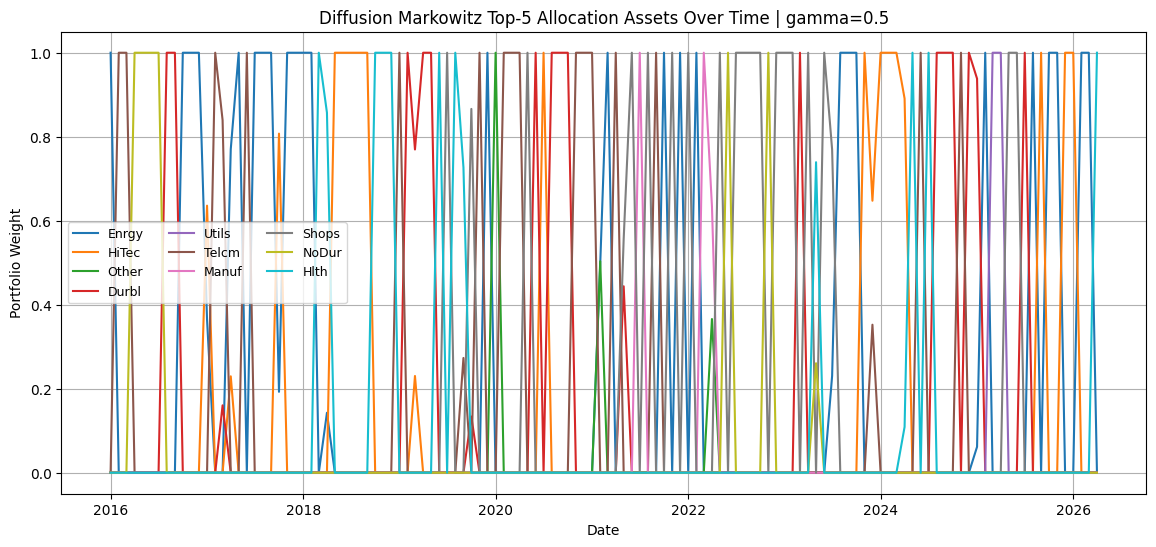

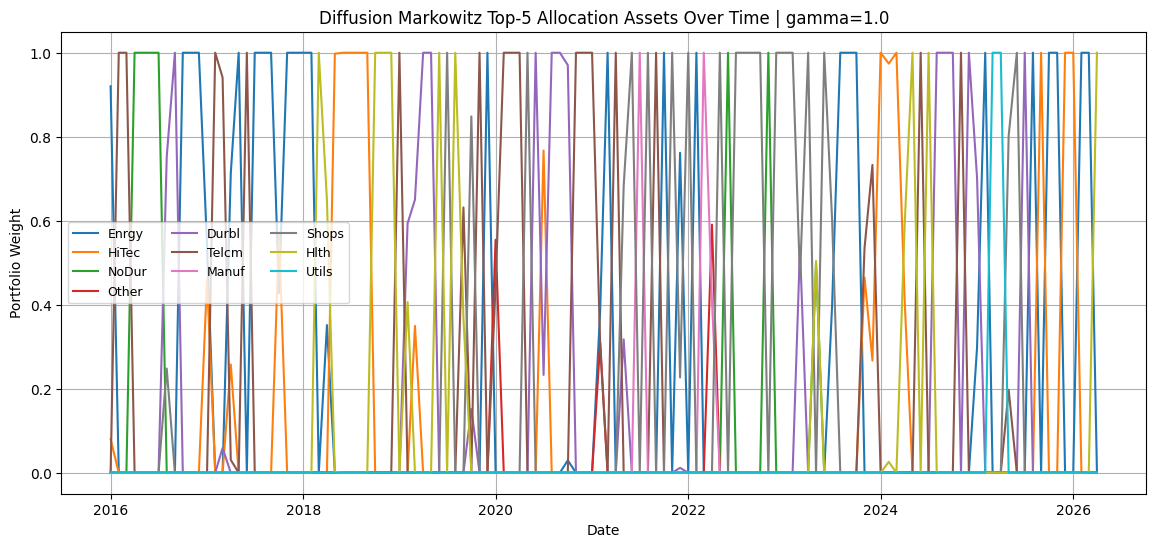

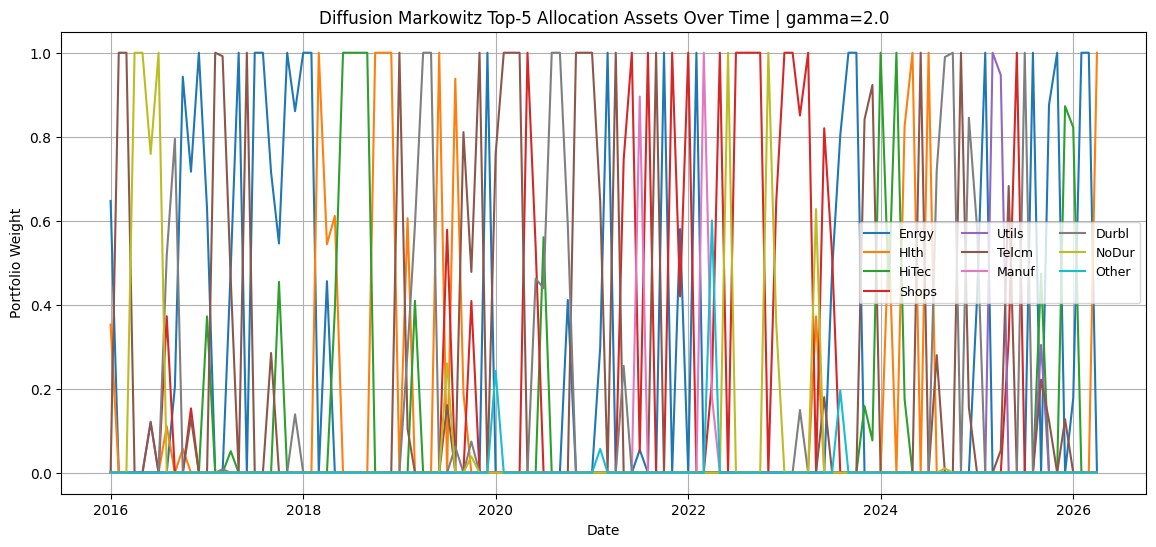

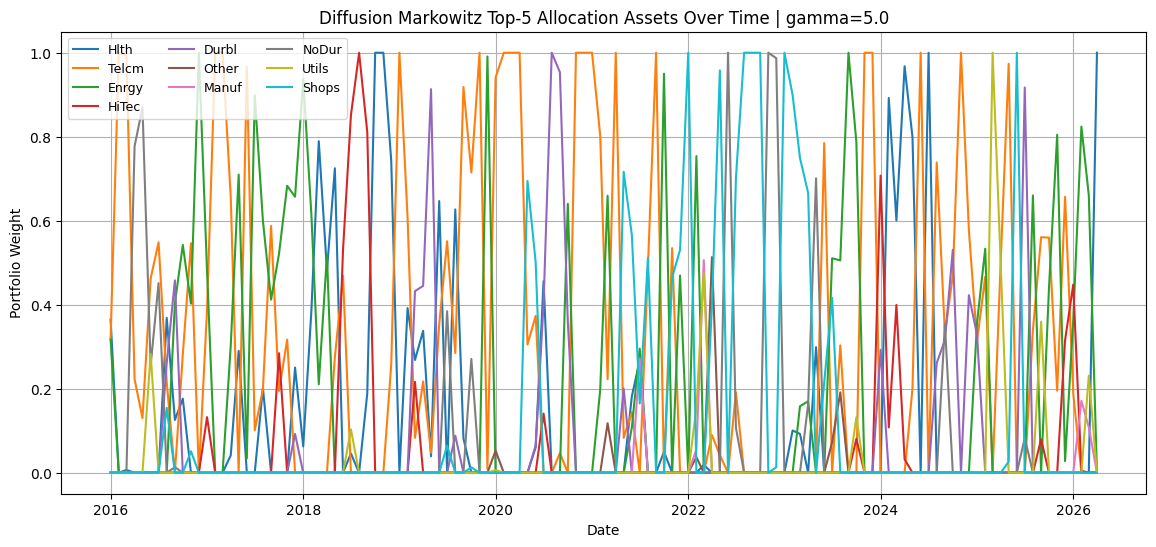

In [25]:
# ============================================================
# Plot top-5 monthly allocation weights
# ============================================================

for gamma in risk_aversions:
    df_g = top5_allocations_df[
        top5_allocations_df["risk_aversion"] == gamma
    ].copy()

    # Assets that ever appear in top 5 for this gamma
    top_assets = df_g["asset"].unique()

    # Build full time-series matrix for those assets
    W = pd.DataFrame(
        ra_weights[gamma],
        index=pd.Index(dates, name="date"),
        columns=asset_names,
    )

    W_top = W[top_assets]

    plt.figure(figsize=(14, 6))

    for asset in top_assets:
        plt.plot(
            W_top.index,
            W_top[asset],
            linewidth=1.5,
            label=asset,
        )

    plt.title(f"Diffusion Markowitz Top-5 Allocation Assets Over Time | gamma={gamma}")
    plt.xlabel("Date")
    plt.ylabel("Portfolio Weight")
    plt.legend(ncol=3, fontsize=9)
    plt.grid(True)
    plt.show()